In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential, layers, callbacks

In [2]:
# Charger MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nPixel range: [{X_train.min()}, {X_train.max()}]")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)

Pixel range: [0, 255]


In [3]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

#  (60000, 28, 28) => (60000, 28, 28, 1) 1 = noir/blanc
#  (60000, 28, 28) => (60000, 28, 28, 3) 3 = rgb
x_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(x_train_cnn.shape)
print(y_train_onehot.shape)

(60000, 28, 28, 1)
(60000, 10)


In [4]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28,28,1), name="conv1"),
    layers.MaxPooling2D((2,2), name="pool1"),

    layers.Conv2D(64, (3, 3), activation="relu", name="conv2"),
    layers.MaxPooling2D((2,2), name="pool2"),

    layers.Flatten(name="flatten"),
    layers.Dense(128, activation="relu", name="dense1"),
    layers.Dense(10, activation="softmax", name="output")
])

model.summary()

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
history = model.fit(
    x_train_cnn, y_train_onehot,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9357 - loss: 0.2234 - val_accuracy: 0.9832 - val_loss: 0.0637
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9823 - loss: 0.0574 - val_accuracy: 0.9895 - val_loss: 0.0437
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9879 - loss: 0.0403 - val_accuracy: 0.9883 - val_loss: 0.0396
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9903 - loss: 0.0312 - val_accuracy: 0.9860 - val_loss: 0.0502
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9927 - loss: 0.0240 - val_accuracy: 0.9897 - val_loss: 0.0361
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9942 - loss: 0.0188 - val_accuracy: 0.9888 - val_loss: 0.0453
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9950 - loss: 0.0155 - val_accuracy: 0.9908 - val_loss: 0.0367
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9960 - loss: 0.0125 - val_accuracy: 0.

In [7]:
test_loss, test_accuracy = model.evaluate(x_test_cnn, y_test_onehot)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9910 - loss: 0.0333
Test Loss: 0.0333
Test Accuracy: 0.9910


In [8]:
# Prédictions sur les 10 premières images
predictions = model.predict(x_test_cnn[:10])
pred_classes = np.argmax(predictions, axis=1)

print("Prédictions vs Labels réels:")
for i in range(10):
    print(f"  Image {i}: Prédiction={pred_classes[i]}, Label réel={y_test[i]}, Correct={pred_classes[i]==y_test[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prédictions vs Labels réels:
  Image 0: Prédiction=7, Label réel=7, Correct=True
  Image 1: Prédiction=2, Label réel=2, Correct=True
  Image 2: Prédiction=1, Label réel=1, Correct=True
  Image 3: Prédiction=0, Label réel=0, Correct=True
  Image 4: Prédiction=4, Label réel=4, Correct=True
  Image 5: Prédiction=1, Label réel=1, Correct=True
  Image 6: Prédiction=4, Label réel=4, Correct=True
  Image 7: Prédiction=9, Label réel=9, Correct=True
  Image 8: Prédiction=5, Label réel=5, Correct=True
  Image 9: Prédiction=9, Label réel=9, Correct=True


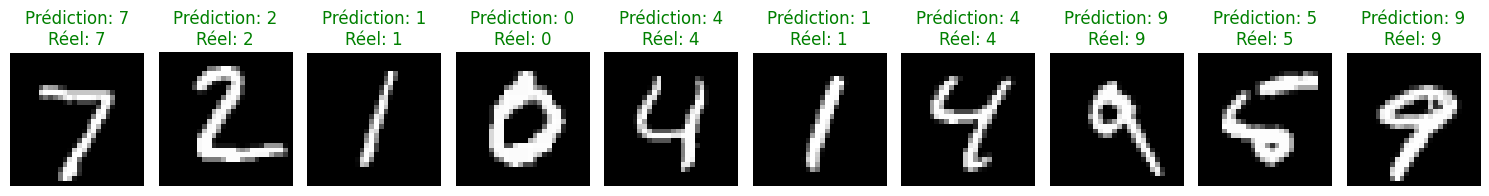

In [9]:
# Visualiser 5 exemples
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i], cmap='gray')
    pred = pred_classes[i]
    true = y_test[i]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Prédiction: {pred}\nRéel: {true}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()